# Vector Field Methods: FMPE and NPSE

`sbi` incorporates recent algorithms based on Flow Matching and Score Matching generative models, which are also referred to as Continuous Normalizing Flows (CNF) and Denoising Diffusion Probabilistic Models (DDPM), respectively.

At the highest level, you can think of FMPE and NPSE as solving the same problem as NPE, i.e., estimating the posterior from simulations, but replacing Normalizing Flows with different conditional density estimators.

Flow Matching and Score Matching, as generative models, are also quite similar to
Normalizing Flows, where a deep neural network parameterizes the transformation from a
base distribution (e.g., Gaussian) to a more complex one that approximates the target
density. In essence, they differ in how they model this transformation, namely by modeling the
vector field of the transformation.

Additionally, Flow Matching and Score Matching offer different benefits and drawbacks
compared to Normalizing Flows, which make them better (or worse) choices for some
problems. For example, Score Matching (Diffusion Models) are known to be very flexible
and can model high-dimensional distributions, but are comparatively slow during
sampling.

### When to use vector field methods over NPE

| | NPE (normalizing flows) | FMPE / NPSE |
|---|---|---|
| **Architecture** | Restricted to invertible transforms | Any neural network |
| **Sampling speed** | Fast (single forward pass) | Slower (ODE/SDE integration) |
| **Scalability** | Limited in very high dims | Better scaling to high dims |
| **Multi-round** | Fully supported | Single-round only |
| **Log-prob** | Exact, fast | Via ODE or SDE (slower) |

### References

**Score Matching:**
- Hyvärinen, A. "Estimation of Non-Normalized Statistical Models by Score Matching." JMLR 2005.
- Song, Y., et al. "Score-Based Generative Modeling through Stochastic Differential Equations." ICLR 2021.
- Geffner, T., et al. "Score modeling for simulation-based inference." ICML 2023.
- Sharrock, L., et al. "Sequential neural score estimation." ICML 2024.
- Karras, T., et al. "Elucidating the Design Space of Diffusion-Based Generative Models." NeurIPS 2022.
- Linhart, J., et al. "Diffusion posterior sampling for simulation-based inference in tall data settings." 2024.

**Flow Matching:**
- Lipman, Y., et al. "Flow Matching for Generative Modeling." ICLR 2023.
- Wildberger, J.B., et al. "Flow Matching for Scalable Simulation-Based Inference." NeurIPS 2023.

## 1. Setup

We use a simple 3D linear Gaussian simulator throughout this tutorial.

In [1]:
import torch
from sbi.analysis import pairplot
from sbi.inference import FMPE, NPSE
from sbi.neural_nets import posterior_flow_nn, posterior_score_nn
from sbi.utils import BoxUniform

In [2]:
# Define prior and simulator
num_dims = 3
num_sims = 10000
num_posterior_samples = 1000
prior = BoxUniform(low=-torch.ones(num_dims), high=torch.ones(num_dims))
labels = [r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"]

def simulator(theta):
    """Linear Gaussian simulator."""
    return theta + 1.0 + torch.randn_like(theta) * 0.1

# Generate training data
theta = prior.sample((num_sims,))
x = simulator(theta)

# Ground truth observation
theta_o = torch.zeros(num_dims)
x_o = simulator(theta_o)

## 2. FMPE — Flow Matching Posterior Estimation

Flow-Matching Posterior Estimation (FMPE) is an approach to SBI that leverages Flow
Matching, a generative modeling technique where the transformation from a simple base
distribution (like a Gaussian) to the target distribution is learned through matching
the flow of probability densities.

The core idea is to model the probability flow between the base distribution and the
target distribution by training a neural network to parameterize a *velocity field* that
defines how samples should be moved or transformed. As such, they learn a continuous
time flow between the source and target distribution and are also referred to as
continuous-time normalizing flows. The velocity field can be represented by an ODE and
sampling from and evaluation the the target distribution then amounts to solving the ODE
forward or backward in time. 

### Step-by-Step Process
1. **Base Distribution**: Start with a simple base distribution (e.g., Gaussian).
2. **Neural Network Parameterization**: Use a neural network to learn a vector field that describes the flow from the base distribution to the target distribution.
3. **Flow Matching Objective**: Optimize the neural network to minimize a loss function that captures the difference between the learned and target vector fields.
4. **Sampling**: Once trained, draw samples from the base distribution and apply the learned flow transformation by solving an ODE to obtain samples from the approximate posterior.

FMPE can be more efficient than traditional normalizing flows in some settings, especially when the target distribution has complex structures or when high-dimensional data is involved (see [Dax et al., 2023](https://arxiv.org/abs/2305.17161) for an example). However, compared to discrete-time normalizing flows, flow matching is usually slower at inference time because sampling requires solving the underlying ODE (compared to just doing a NN forward pass for normalizing flows).

**Key properties:**
- Default sampling: `sample_with="ode"` (fast, deterministic)
- Through the conceptual and mathematical connection to score matching (see below), it
  also supports sampling via an SDE.

 Neural network successfully converged after 114 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

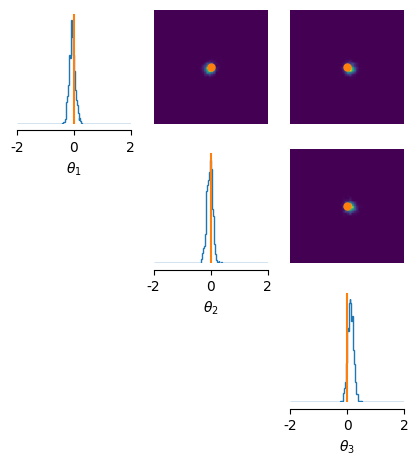

In [3]:
# Minimal FMPE example
fmpe_trainer = FMPE(prior)
fmpe_trainer.append_simulations(theta, x).train()
fmpe_posterior = fmpe_trainer.build_posterior()
samples_fmpe = fmpe_posterior.sample((num_posterior_samples,), x=x_o)

fig, ax = pairplot(
    samples_fmpe, limits=[[-2, 2]] * 3, figsize=(5, 5),
    labels=labels,
    points=theta_o,
)

## 3. NPSE — Neural Posterior Score Estimation

NPSE approximates a target posterior distribution $p_0(\theta|x_0)$ by learning its
*score function*, i.e., the gradient of the log-density of the (diffused) posterior
$\nabla_{\theta}\log p_t(\theta|x)$, for all times $t$ and all conditional observations
$x$, using the denoising score matching loss. Score-based generative models are closely
linked to diffusion models, especially during the sampling phase. 

The core idea of diffusion models is that one can learn complex distributions from data
by gradually adding noise to the data until it is pure noise (e.g., a Gaussian), while
learning the mathematical representation of these noise additions (the score function)
along the way. Crucually, there is a mathematical way to also represent the reverse
direction, i.e., the _denoising_ steps. Therefore, after training, one can also start
with as simple noise distribution and obtain samples from the target distribution by
gradually applying the learnt denoising steps. 

Sampling from the target posterior $p_0(\theta|x_0)$ can be split into two steps: -
**Forward step**: Diffuse samples from $p_0(\theta|x_0)$ over time and learn the
diffused scores $\nabla_{\theta}\log p_t(\theta|x)$ for all $t \in [0, t_{\max}]$. At
the end ($t=t_{\max}$), the diffused posterior is close to a standard Gaussian. -
**Reverse step**: Reverse the diffusion process, starting from a standard Gaussian,
using the learned scores to generate new samples from $p_0(\theta|x_0)$.

Score-based generative models have been shown to scale well to very high dimensions (e.g., high-resolution images), which is particularly useful when the parameter space is high-dimensional. On the other hand, sampling can be slower as it involves solving many steps of the stochastic differential equation for reversing the diffusion process.

For more details on score-based generative models, see [Song et al., 2020](https://arxiv.org/abs/2011.13456) (in particular, Figures 1 and 2).

Note that only the **single-round** version of NPSE is implemented currently.

In `sbi`, the `sde_type` parameter defines whether the forward diffusion process has a noising schedule that is Variance Exploding (`"ve"`, i.e., [SMLD](https://proceedings.neurips.cc/paper/2019/hash/3001ef257407d5a371a96dcd947c7d93-Abstract.html)), Variance Preserving (`"vp"`, i.e., [DDPM](https://proceedings.neurips.cc/paper/2020/hash/4c5bcfec8584af0d967f1ab10179ca4b-Abstract.html)), or sub-Variance Preserving (`"subvp"`).

 Neural network successfully converged after 170 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

Generating 1000 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

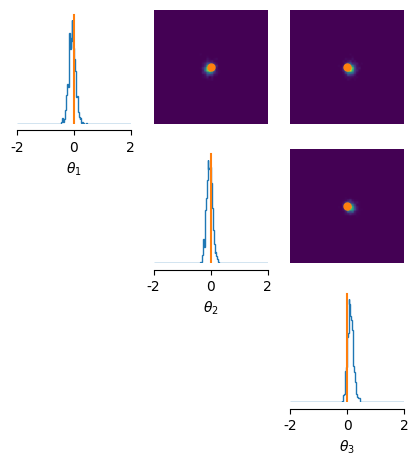

In [4]:
# Minimal NPSE example
npse_trainer = NPSE(prior, sde_type="ve")
npse_trainer.append_simulations(theta, x).train()
npse_posterior = npse_trainer.build_posterior()
samples_npse = npse_posterior.sample((num_posterior_samples,), x=x_o)

fig, ax = pairplot(
    samples_npse, limits=[[-2, 2]] * 3, figsize=(5, 5),
    labels=labels,
    points=theta_o,
)

## 4. Network Architectures

While NPE is architecturally limited to conditional density networks (normalizing flows), both FMPE and NPSE solve a **regression problem** targeting a specific *vector field* (e.g., marginal scores or transport velocities). This is advantageous because it allows us to use any "off-the-shelf" neural network, in contrast to NPE, which is typically restricted to normalizing flows.

However, performance can be highly dependent on the suitability of the chosen neural network for the task at hand. For instance, diffusion models achieve state-of-the-art generative performance on images only when paired with a carefully designed U-Net-like architecture.

For both FMPE and NPSE, we provide a selection of neural networks tailored to the task:
- `"mlp"` and `"ada_mlp"` (MLP with adaptive layer norm for conditioning) — MLP variants that inject time information at each layer, as is common in diffusion architectures.
- `"transformer"` and `"transformer_cross_attn"` — scalable diffusion transformers (e.g., as in [Peebles & Xie, 2023](https://arxiv.org/abs/2212.09748)). The cross-attention variant supports arbitrary sequence lengths for conditioning.

For certain data types, such as image-like inputs, it may still be beneficial to use a more specialized architecture.

Use `posterior_flow_nn()` for FMPE and `posterior_score_nn()` for NPSE to configure the network.

In [5]:
# FMPE with a transformer architecture
net_builder = posterior_flow_nn(
    model="transformer",
    num_layers=2,
    num_heads=2,
    hidden_features=64,
)
trainer = FMPE(prior, vf_estimator=net_builder)
estimator = trainer.append_simulations(theta, x).train(
    training_batch_size=200, learning_rate=5e-4
)

 Neural network successfully converged after 123 epochs.

In [6]:
# NPSE with custom network configuration via posterior_score_nn
net_builder = posterior_score_nn(
    model="mlp",
    sde_type="ve",
    hidden_features=128,
    num_layers=6,
)
trainer = NPSE(prior, vf_estimator=net_builder)
estimator = trainer.append_simulations(theta, x).train()

 Neural network successfully converged after 87 epochs.

### Custom networks via the `VectorFieldNet` protocol

You can use your custom network for estimating the vector field, essentially any
`torch.nn.Module` that follows the `VectorFieldNet` protocol: it must accept `(theta, x,
t)` and return a tensor with the same shape as `theta`.

In [7]:
from sbi.utils.vector_field_utils import VectorFieldNet

class CustomNet(VectorFieldNet):
    def __init__(self):
        super().__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Linear(3 + 3 + 1, 128),  # theta_dim + x_dim + 1; adapt these to your problem
            torch.nn.GELU(),
            torch.nn.Linear(128, 128),
            torch.nn.GELU(),
            torch.nn.Linear(128, 3),  # must match theta_dim
        )

    def forward(self, theta, x, t):
        h = torch.cat([theta, x, t[..., None]], dim=-1)
        return self.layers(h)

# Wrap in the factory function (adds z-scoring).
net_builder = posterior_flow_nn(model=CustomNet())
trainer = FMPE(prior, vf_estimator=net_builder)
estimator = trainer.append_simulations(theta, x).train()

 Neural network successfully converged after 160 epochs.

## 5. Noise Schedules and Training Options

In score matching, the noise schedule defines the way we add noise to the target data
across time. Per default, this noise is added uniformly across time. However, it has
been shown that for some problems performance can be improved by having a dedicated
_noise schedule_ that is not uniform across time [Karras et al.
2022](https://arxiv.org/abs/2206.00364). In `sbi` we therefore implemented an option to
pass different noise schedules for the `NPSE` training phase and the sampling phase.

All SDE types have tunable noise range parameters:
- **VE**: `sigma_min` / `sigma_max` (default: 1e-4, 10.0) — controls the range of noise added during diffusion.
- **VP / SubVP**: `beta_min` / `beta_max` (default: 0.01, 10.0) — controls the linear noise schedule.

These can be passed as `**kwargs` to `posterior_score_nn()` and are validated by `ScoreEstimatorConfig`.

### EDM-style time sampling schedules (VE only)

For NPSE with `sde_type="ve"`, you can use EDM-style schedules from [Karras et al. 2022](https://arxiv.org/abs/2206.00364):
- `train_schedule="lognormal"`: Concentrates training on intermediate noise levels where the score is most informative.
- `solve_schedule="power_law"`: Concentrates sampling steps near low noise levels for sharper samples.

In [8]:
# NPSE with EDM-style noise schedules
net_builder = posterior_score_nn(
    model="mlp",
    sde_type="ve",
    # EDM-style training schedule
    train_schedule="lognormal",
    lognormal_mean=-1.2,
    lognormal_std=1.2,
    # EDM-style solving schedule
    solve_schedule="power_law",
    power_law_exponent=7.0,
    # Noise range
    sigma_min=1e-3,  # default: 1e-4
    sigma_max=15.0,  # default: 10.0; increased for broader prior
)
trainer = NPSE(prior, vf_estimator=net_builder)
trainer.append_simulations(theta, x).train()
posterior = trainer.build_posterior()

 Neural network successfully converged after 196 epochs.

## 6. A bridge between FMPE and NPSE. Sampling with SDE vs ODE

It has been shown that a under trained flow matching model (FMPE) implicitly defines a
score function, and therefore also an SDE that can be used for stochastic sampling,
exactly like NPSE [Singh et al., 2024](https://arxiv.org/abs/2410.02217). This can be
useful for SBI because SDE-based score methods have some additional benefits over FMPE,
e.g., sampling complex posterior shapes,  posterior sampling given i.i.d. data, or
_guidance_ (see below).

Practially in `sbi` this implies that both FMPE and NPSE support **both** SDE and ODE
sampling. Per default FMPE uses `sample_with="ode"` (deterministic, fast) and NPSE uses
`sample_with="sde"` (stochastic, more robust). However, The `sample_with` argument
allows you to choose which kind of solver to use to reverse the diffusion equation:

- `"ode"`: Builds the probability flow ODE using the `zuko` library. Sampling is deterministic and typically faster.
- `"sde"`: Solves the reverse SDE by alternating **prediction** and **correction**
  steps. The only available predictor is `"euler_maruyama"` and the available correctors
  are `"langevin"` (for Unadjusted Langevin Dynamics) and `"gibbs"` (for Gibbs
  sampling).

Both options include **rejection sampling** steps to ensure samples remain within the prior support.

For SDE sampling, you can configure:
- `predictor`: Integration scheme (default: `"euler_maruyama"`)
- `corrector`: Optional correction step (`None`, `"langevin"`, `"gibbs"`)
- `steps`: Number of integration steps (default: 500)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Generating 1000 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

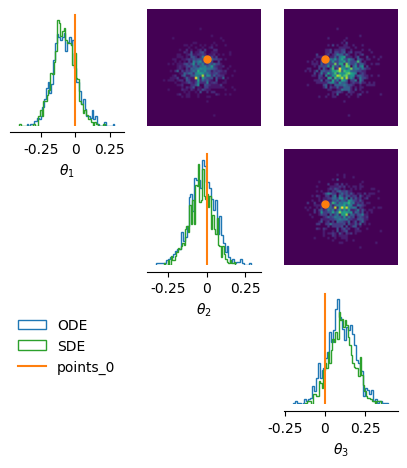

In [9]:
# We can sample from a FMPE posterior using ODE or SDE sampling.
# ODE sampling (faster, deterministic)
posterior_ode = fmpe_trainer.build_posterior(estimator, sample_with="ode")
samples_ode = posterior_ode.sample((num_posterior_samples,), x=x_o)

# SDE sampling (stochastic, can be more robust)
posterior_sde = fmpe_trainer.build_posterior(estimator, sample_with="sde")
samples_sde = posterior_sde.sample((num_posterior_samples,), x=x_o)

fig, axes = pairplot(
    [samples_ode, samples_sde],
    figsize=(5, 5),
    labels=labels,
    points=theta_o,
    legend=True,
    samples_labels=["ODE", "SDE"],
)

## 7. MAP Estimation

It is possible to get a Maximum A Posteriori (MAP) estimate with both FMPE and NPSE. The optimization procedure (gradient ascent) finds a maximizer $\theta_{\max}$ of the posterior log-probability $\log p(\theta|x_0)$.

The default values (number of optimization steps, starting positions, learning rate) might require hand-tuning for your problem.

In [ ]:
# MAP estimation (works for both FMPE and NPSE)
fmpe_posterior = fmpe_posterior.set_default_x(x_o)

map_estimate = fmpe_posterior.map(num_iter=50, learning_rate=0.01, show_progress_bars=True)

  0%|          | 0/1000 [00:00<?, ?it/s]

 Optimizing MAP estimate. Iterations: 95 / 100. Performance in iteration 0: 4.02 (= unnormalized log-prob). Press Ctrl-C to interrupt.Optimization was interrupted after 95 iterations. 


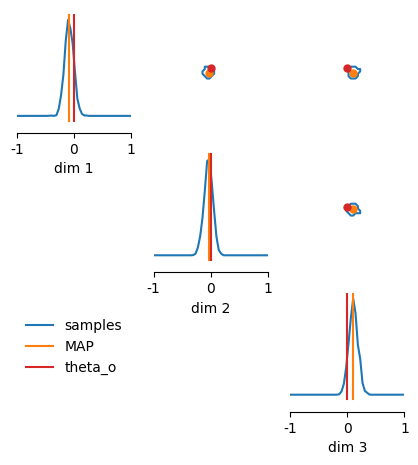

In [11]:
# Plot posterior samples and MAP
fig, ax = pairplot(
    samples_sde,
    figsize=(5, 5),
    limits=[[-1, 1]] * 3,
    diag = "kde",
    upper="contour",
    diag_kwargs=dict(bins=100),
    upper_kwargs=dict(levels=[0.95]),
    points=[map_estimate, theta_o.unsqueeze(0)], # add ground truth thetas and MAP
    points_labels=["MAP", "theta_o"],
    samples_labels=["samples"],
    legend=True,
)

## 8. Batched Sampling

Given a batch of observations $[x_1, \ldots, x_B]$ (not i.i.d.), it is possible to get samples from posteriors $p(\theta|x_1)$, ..., $p(\theta|x_B)$ in a vectorized manner without retraining! This is implemented in the `sample_batched()` method. The argument `sample_shape` specifies the desired number of samples for **each** posterior.

In [12]:
# Generate a batch of observations
x_batch = simulator(prior.sample((5,)))  # 5 different observations

# Batched sampling: returns shape (num_samples, num_observations, num_dims)
samples_batch = fmpe_posterior.sample_batched(
    sample_shape=(1_000,),
    x=x_batch,
)
print(f"Batched samples shape: {samples_batch.shape}")

Drawing 1000 samples for 5 observations:   0%|          | 0/1000 [00:00<?, ?it/s]

Batched samples shape: torch.Size([1000, 5, 3])


## 9. IID / Tall Posteriors

When $x_0$ is a batch of **i.i.d.** observations $x_0 = [x_0^0, \ldots, x_0^N]$, it is
possible to sample from the *tall* posterior distribution $p(\theta|x_0^0, \ldots,
x_0^N)$ by aggregating the i.i.d. observations on the score-level ([Geffner et al.,
2023](https://arxiv.org/abs/2209.14249)). Thanks to the FMPE-NPSE bridge, this also works
for FMPE by switching the SDE at inference / sampling time.

Once the score/velocity estimate is trained, sampling from $p(\theta|x_0^0, \ldots, x_0^N)$ is split into two steps:
1. Estimate the scores of the *tall* posterior for all times $t$, based on the learned scores of **individual** posteriors $p(\theta|x_0^i)$.
2. Reverse the diffusion process or solve the SDE using the estimated scores.

To sample, call `.sample()` as before but pass a **batch** of observations to `x` — the algorithm will assume those to be i.i.d. and automatically switch to the tall posterior setting.

The `iid_method` argument specifies the method used to estimate the scores of the tall posterior using the individual posterior scores:
- `"auto_gauss"` (recommended): Auto-calibrates Gaussian approximation of the marginal score. Has initial overhead but is accurate and robust. See [Linhart et al., 2024](https://arxiv.org/abs/2404.07593).
- `"gauss"`: Faster Gaussian approximation, good for simple problems. See [Linhart et al., 2024](https://arxiv.org/abs/2404.07593).
- `"jac_gauss"`: Most accurate, uses iterative Jacobian computations (expensive). See [Linhart et al., 2024](https://arxiv.org/abs/2404.07593).
- `"fnpe"`: Factorized Neural Posterior Estimation — simple and fast, but can become inaccurate for many observations due to heuristic approximations. See [Geffner et al., 2023](https://arxiv.org/abs/2209.14249).

In [13]:
# Re-use the NPSE posterior trained on single observations from above.
posterior = npse_trainer.build_posterior(sample_with="sde")

# Generate i.i.d. observations from the same ground truth
num_iid_samples = 10
x_iid = torch.stack([simulator(theta_o) for _ in range(num_iid_samples)])

# Sample from the tall posterior
samples_iid = posterior.sample(
    (num_posterior_samples,), x=x_iid,
    iid_method="auto_gauss",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

Generating 1000 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

### Progressive sharpening with more observations

The posterior concentrates around the true parameter as the number of i.i.d. observations increases.

In [14]:
# Compare posteriors with different numbers of i.i.d. observations
x_iid_20 = torch.stack([simulator(theta_o) for _ in range(20)])
all_samples = []
labels = []
for n_obs in [1, 5, 10, 20]:
    x_subset = x_iid_20[:n_obs]
    samples = posterior.sample((1_000,), x=x_subset)
    all_samples.append(samples)
    labels.append(f"N={n_obs}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Generating 1000 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Generating 1000 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Generating 1000 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Generating 1000 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

/Users/janteusen/qode/sbi/sbi/inference/potentials/vector_field_adaptor.py:1254: UserWarning: Capping max_sampling_batch_size from 10000 to 5000 to avoid excessive memory usage.
  thetas = posterior.sample_batched(


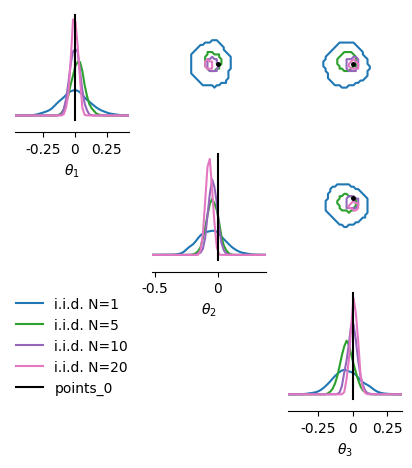

In [ ]:
fig, axes = pairplot(
    all_samples,
    figsize=(5, 5),
    points=theta_o.unsqueeze(0),  # add batch dimension for plotting
    points_colors=["k"],
    labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"],
    diag="kde",
    upper="contour",
    upper_kwargs=dict(levels=[0.99]),
    points_offdiag=dict(markersize=5),
    legend=True,
    samples_labels=[f"i.i.d. N={n}" for n in [1, 5, 10, 20]],
);

## 10. Guidance Methods

Guidance methods allow post-hoc modifications to the posterior without retraining. The
core idea is that the learned posterior score can be decomposed into a prior score and a
likelihood score. Since we know the prior analytically, we can compute the prior score
at any diffusion time in closed form, and then obtain the likelihood score as the difference between the learned posterior score and the prior score. Once decomposed, we can independently modify each component — for
example, scaling up the likelihood score to sharpen the posterior, or swapping the prior
score for a different prior — and then recombine them for sampling. This is powerful for SBI because it means you train once and can then adjust the posterior at inference time for different priors, sharper or flatter posteriors, or
addi

Thus, if we want to do certain modifications to our model after training, e.g.:
- Shifting prior/likelihood location/scale.
- Truncating the prior.
- Changing the prior to a different distribution, 

then diffusion-based **guidance** is a way to do so. In `sbi`, we implemented several
guidance methods to perform such operations. Note that guidance affects `.sample()`
only, `.log_prob()` and `.map()` are not supported with active guidance.

### Affine Classifier-Free Guidance

The following classifier-free guidance method allows you to scale and shift the prior and likelihood score contributions. This can be used to perform "super" conditioning, i.e., shrink the variance of the likelihood:

 Neural network successfully converged after 91 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

Generating 1000 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Generating 1000 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

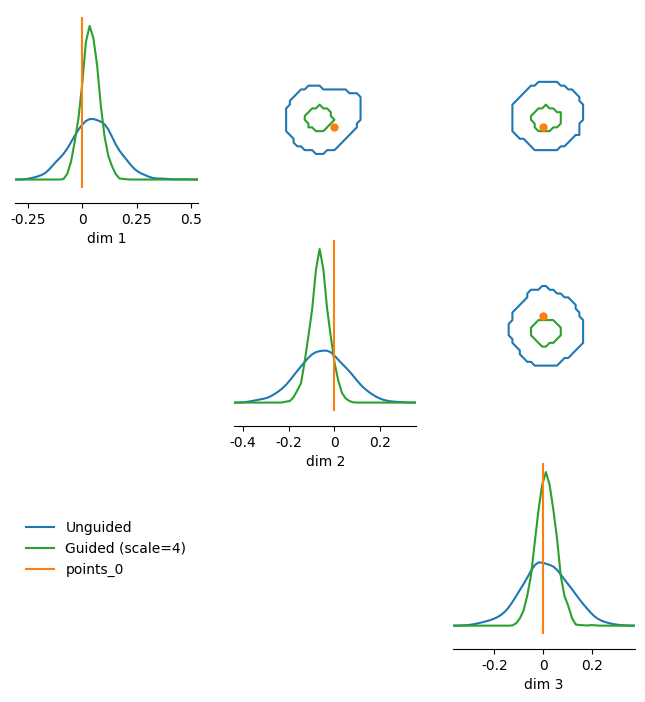

In [ ]:
# Affine classifier-free guidance: sharpen the posterior
from torch.distributions import MultivariateNormal

# Train with Gaussian prior.
prior = MultivariateNormal(loc=torch.zeros(num_dims), covariance_matrix=torch.eye(num_dims))
theta = prior.sample((num_sims,))
x = simulator(theta)
trainer = NPSE(prior)
trainer.append_simulations(theta, x).train()
posterior = trainer.build_posterior(sample_with="sde")
theta_o = torch.zeros(num_dims)
x_o = simulator(theta_o)

# Guidance parameters: increase likelihood scale to sharpen the posterior
guidance_params = {
    "likelihood_scale": 4.0,  # increase the likelihood precision (-> narrower posterior)
    "prior_scale": 1.,  # same prior precision
    "prior_shift": 0.,  # same prior mean
    "likelihood_shift": 0.,  # same likelihood mean
}

# Unguided
samples_unguided = posterior.sample((1_000,), x=x_o)

# Guided: increase likelihood scale to sharpen, no re-training.
samples_guided = posterior.sample(
    (1_000,), x=x_o,
    guidance_method="affine_classifier_free",
    guidance_params=guidance_params,
)

fig, axes = pairplot(
    [samples_unguided, samples_guided],
    figsize=(8, 8),
    diag="kde",
    upper="contour",
    upper_kwargs=dict(levels=[0.99]),
    points=theta_o.unsqueeze(0),
    legend=True,
    samples_labels=["Unguided", "Guided (scale=4)"],
)

### Prior Guidance

A more general method is **prior guidance**, which allows you to specify arbitrary training and test priors (see [Yang et al., 2025](https://arxiv.org/abs/2510.13763)). The only requirement is that the test prior should be covered by the training prior — otherwise the guidance will push samples outside the training distribution where the score estimates will be poor.

Below we exchange the training prior (standard normal) for a shifted multivariate normal prior with correlations:

  0%|          | 0/1000 [00:00<?, ?it/s]

Generating 1000 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

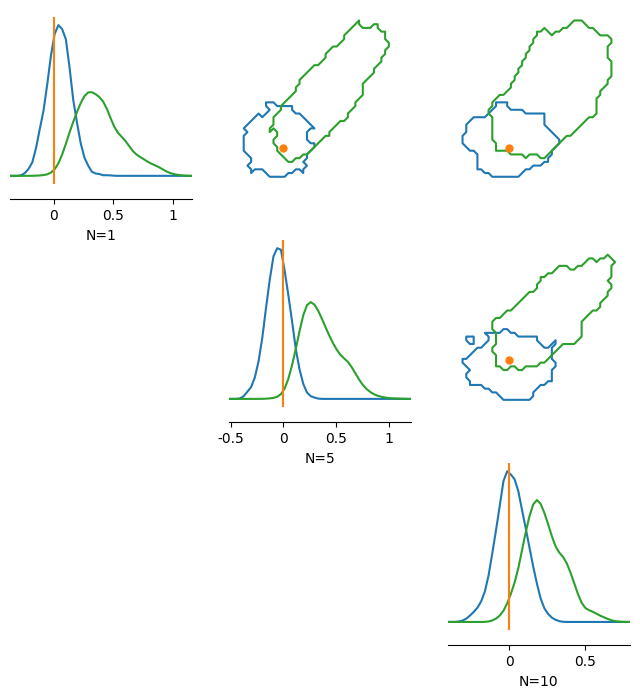

In [23]:
from torch.distributions import MultivariateNormal

# Broad prior from above.
train_prior = prior

# Test with a shifted, correlated prior
test_prior = MultivariateNormal(
    loc=torch.zeros(num_dims) + 0.1,
    covariance_matrix=torch.tensor([[0.5, 0.3, 0.1],
                      [0.3, 0.4, 0.2],
                      [0.1, 0.2, 0.3]])
)

# For more complicated adjustments we need a larger K (number of mixture components for
# approximating the prior).
guidance_params = {
    "test_prior": test_prior,
    "train_prior": train_prior,
    "K": 8,
    "covariance_type": "full"  # Required for adding new correlations!
}

# No need to train again, just plug in the new guidance parameters when sampling.
samples_prior_guided = posterior.sample(
    (1_000,),
    x=x_o,
    guidance_method="prior_guide",
    guidance_params=guidance_params,
)

pairplot(
    [samples_unguided, samples_prior_guided],
    points=theta_o.unsqueeze(0),
    figsize=(8, 8),
    diag="kde",
    upper="contour",
    upper_kwargs=dict(levels=[0.99]),
    labels=labels,
);

## Summary

| Feature | FMPE | NPSE |
|---|---|---|
| What it learns | Velocity field | Score function |
| Default sampling | ODE | SDE |
| SDE types | N/A | `"ve"`, `"vp"`, `"subvp"` |
| Noise range params | N/A | `sigma_min/max` (VE), `beta_min/max` (VP) |
| EDM schedules | N/A | `train_schedule`, `solve_schedule` |
| MAP estimation | Yes | Yes |
| Batched sampling | Yes | Yes |
| IID posteriors | Yes | Yes |
| Guidance | Yes | Yes |
| Multi-round | Not supported | Not supported |

For practical guidance on choosing between options, see the how-to guide: [How to Choose Vector Field Options](../how_to_guide/24_choosing_vector_field_options.ipynb).